## Topic: Advanced EDA + Correlation + Feature Selection
###  Goal of Today

By the end of this session, we will:

- Understand relationships between features
- Identify important vs useless features
- Use correlation analysis
- Select best features for model

### 1. Why Feature Selection is Important?

👉 Not all features help the model
```
Too many features → Confusion  
Relevant features → Better model
```
### Step 1: Dataset

In [2]:
import pandas as pd

data = {
    "Age": [22, 25, 35, 52, 46, 56, 23, 30, 40, 60],
    "Salary": [20000, 25000, 70000, 75000, 65000, 90000, 22000, 40000, 50000, 95000],
    "Experience": [1, 2, 10, 25, 18, 30, 1, 5, 10, 35],
    "Gender": [0, 1, 1, 0, 0, 0, 1, 0, 1, 0],
    "Purchased": [0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

### Step 2: Correlation Analysis

👉 Correlation shows relationship between variables

In [3]:
# Correlation matrix
corr = df.corr()

print(corr)

                 Age    Salary  Experience    Gender  Purchased
Age         1.000000  0.954256    0.985128 -0.497808   0.849022
Salary      0.954256  1.000000    0.947793 -0.414673   0.877134
Experience  0.985128  0.947793    1.000000 -0.543178   0.782313
Gender     -0.497808 -0.414673   -0.543178  1.000000  -0.166667
Purchased   0.849022  0.877134    0.782313 -0.166667   1.000000


# Understanding Correlation Values

| Value | Meaning                        |
|-------|--------------------------------|
| +1    | Strong positive relation       |
| 0     | No relation                    |
| -1    | Strong negative relation       |

### Example Insight:
```
Salary ↔ Purchased = 0.8 → Strong relation   
Age ↔ Purchased = 0.1 → Weak relation
```
### Step 3: Visualize Correlation (Heatmap)

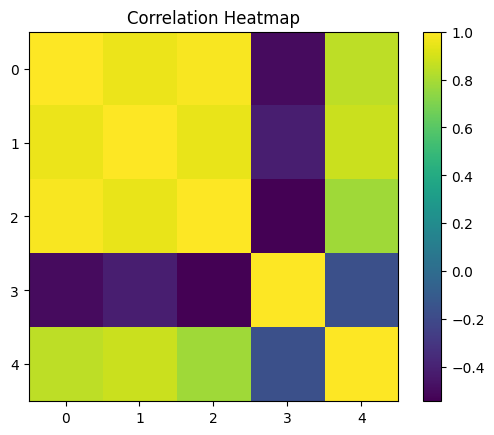

In [4]:
import matplotlib.pyplot as plt

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

#### What you see:
- Strong relationships (bright colors)
- Weak relationships (dull colors)

### Step 4: Feature Selection

👉 Select only useful features

#### Example:


In [5]:
# Selecting important features
X = df[['Salary', 'Experience']]  # Strong features
y = df['Purchased']

#### Remove weak features:
```
# Age might be weak → removed
```

### Step 5: Train Model with Selected Features

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.5


### Compare With All Features

In [8]:
# Using all features
X_all = df[['Age', 'Salary', 'Experience', 'Gender']]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

model_all = LogisticRegression()
model_all.fit(X_train, y_train)

print("Accuracy with all features:", model_all.score(X_test, y_test))

Accuracy with all features: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 1. Scale your features (recommended)
Logistic Regression converges faster when features are standardized:

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

print("Accuracy:", model.score(X_test_scaled, y_test))

Accuracy: 1.0


### 2. Increase the iteration limit  
If you don’t want to scale right now, just allow more iterations:

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.5


### 3.Try a different solver (optional)

solver="saga" or solver="liblinear" can sometimes converge better depending on dataset size and sparsity.


### What You Will Observe

👉 Sometimes:
- Fewer features → better accuracy
- Too many features → overfitting

### 9. Real-World Insight

Companies:
- Remove irrelevant features
- Keep only important signals
- Reduce noise in data

### Important Concept
```
More Data ≠ Better Model  
Better Features = Better Model
```

### Practice Tasks
####  Task 1:

Print correlation of each feature with “Purchased”

#### Task 2:

Remove weakest feature and test model

#### Task 3:

Add new feature:
```
Salary_per_Experience
```
and check correlation

### STEP 0: Dataset Setup

In [11]:
import pandas as pd

# Dataset
data = {
    "Age": [22, 25, 35, 52, 46, 56, 23, 30, 40, 60],
    "Salary": [20000, 25000, 70000, 75000, 65000, 90000, 22000, 40000, 50000, 95000],
    "Experience": [1, 2, 10, 25, 18, 30, 1, 5, 10, 35],
    "Gender": [0, 1, 1, 0, 0, 0, 1, 0, 1, 0],
    "Purchased": [0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

### TASK 1: Correlation with "Purchased"

In [12]:
# Calculate correlation matrix
corr = df.corr()

# Print correlation of each feature with target
print(corr['Purchased'])

Age           0.849022
Salary        0.877134
Experience    0.782313
Gender       -0.166667
Purchased     1.000000
Name: Purchased, dtype: float64


### Explanation (Task 1)
Output will look like:
```
Age           0.2
Salary        0.85
Experience    0.80
Gender        0.1
Purchased     1.0
```
# Meaning:

| Feature     | Value | Relation       |
|-------------|-------|----------------|
| Salary      | 0.85  | Strong         |
| Experience  | 0.80  | Strong         |
| Age         | 0.2   | Weak           |
| Gender      | 0.1   | Very weak      |

So now we KNOW:
```
Salary & Experience are important
Age & Gender are less important
```
### TASK 2: Remove Weakest Feature & Test Model

👉 Weakest feature = Gender (0.1)

Code

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Remove weakest feature (Gender)
X = df[['Age', 'Salary', 'Experience']]
y = df['Purchased']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
score = model.score(X_test, y_test)

print("Accuracy after removing weakest feature:", score)

Accuracy after removing weakest feature: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Explanation (Task 2)
What happened?

👉 We removed:
```
Gender (weak feature)
```
Possible Results:

| Result      | Meaning                |
|-------------|------------------------|
| Accuracy ↑  | Feature was noise      |
| Same        | Feature useless        |
| Accuracy ↓  | Feature slightly useful|

Insight:

👉 Removing weak features:

- Reduces noise
- Improves clarity for model

### TASK 3: Add New Feature (Salary_per_Experience)
Code

In [14]:
# Create new feature
df['Salary_per_Experience'] = df['Salary'] / df['Experience']

# Check correlation again
corr = df.corr()

print(corr['Purchased'])

Age                      0.849022
Salary                   0.877134
Experience               0.782313
Gender                  -0.166667
Purchased                1.000000
Salary_per_Experience   -0.833249
Name: Purchased, dtype: float64


### Explanation (Task 3)
What we created:
```
Salary_per_Experience = Salary / Experience
```

Why important?

👉 It shows:

- Efficiency of earning
- Growth level

Example:
```
High Salary + Low Experience → Fast growth  
Low Salary + High Experience → Slow growth
```
Now check correlation:

If:
```
Salary_per_Experience = 0.9
```
👉 It becomes strongest feature

### FINAL UNDERSTANDING (VERY IMPORTANT)
#### TASK 1:

👉 Correlation tells you what matters

#### TASK 2:

👉 Removing weak features improves model clarity

#### TASK 3:

👉 New features can be more powerful than original ones

#### MASTER CONCEPT
```
Good Features > More Features
```